In [ ]:
print('test')

[1] "test"


In [ ]:
# 1. Carregar os pacotes necessários
install.packages(c("readr", "dplyr", "forecast", "tseries", "tidyr", "readxl")) # Rode apenas na 1ª vez
library(readr)
library(dplyr)
library(forecast)
library(tseries)
library(readxl)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘quadprog’, ‘quantmod’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [ ]:

dados_cidades <- read_excel("./STATISTICS_MAPBIOMAS_AGUA_COL4_CITY-STATE-BIOME-SUB_BASINS_DOI.xlsx")

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`


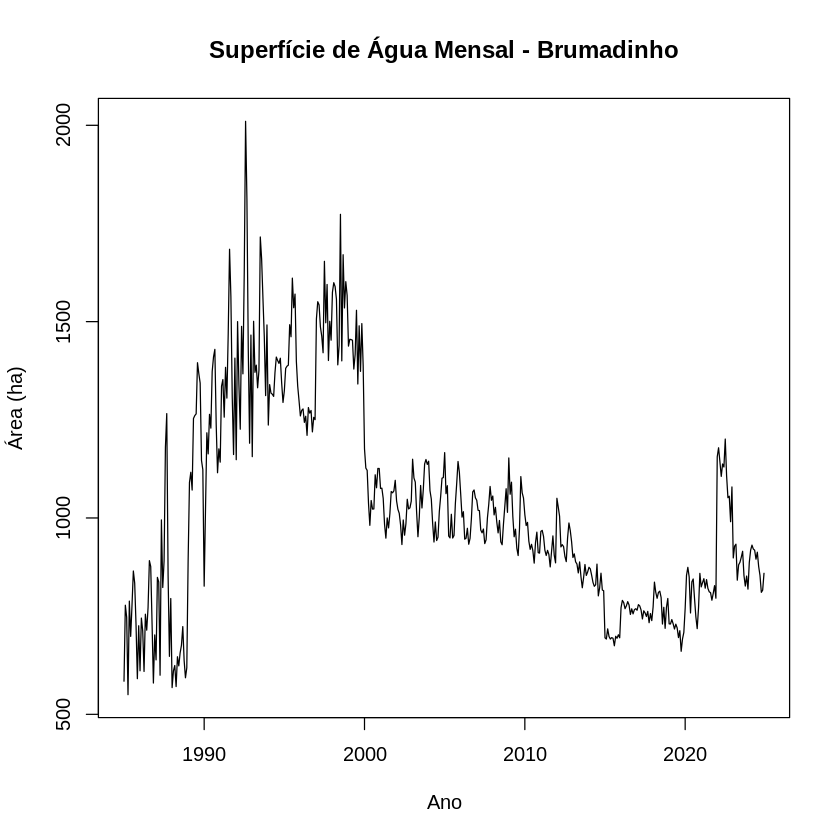

In [ ]:
# 2. Carregar a base de dados direto do Excel
# Faça o upload do arquivo .xlsx original para o menu lateral do Colab
nome_arquivo <- "STATISTICS_MAPBIOMAS_AGUA_COL4_CITY-STATE-BIOME-SUB_BASINS_DOI.xlsx"

# Lê especificamente a aba (worksheet) com os dados mensais por cidade
dados_cidades <- read_excel(nome_arquivo, sheet = "WATER_CITY_MENSAL")

# 3. Filtrar os dados de Brumadinho e ordenar
dados_brumadinho <- dados_cidades %>%
  filter(municipality == "Brumadinho") %>%
  arrange(year)

# Extrair apenas as colunas de janeiro a dezembro e transformar num vetor contínuo
matriz_meses <- dados_brumadinho %>%
  select(january:december) %>%
  as.matrix()

vetor_agua <- as.numeric(t(matriz_meses))

# 4. Criar o objeto de Série Temporal
ts_brumadinho <- ts(vetor_agua, start = c(1985, 1), frequency = 12)

# Daqui em diante, o código segue normal...
plot(ts_brumadinho, main = "Superfície de Água Mensal - Brumadinho", ylab = "Área (ha)", xlab = "Ano")

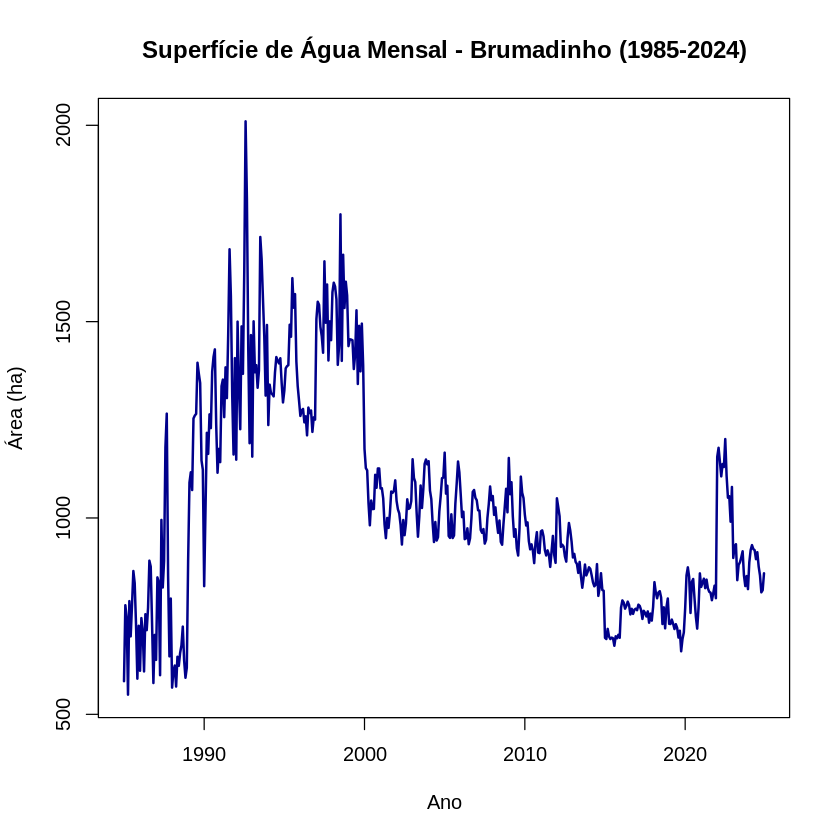


	Augmented Dickey-Fuller Test

data:  ts_brumadinho
Dickey-Fuller = -3.0513, Lag order = 7, p-value = 0.1333
alternative hypothesis: stationary


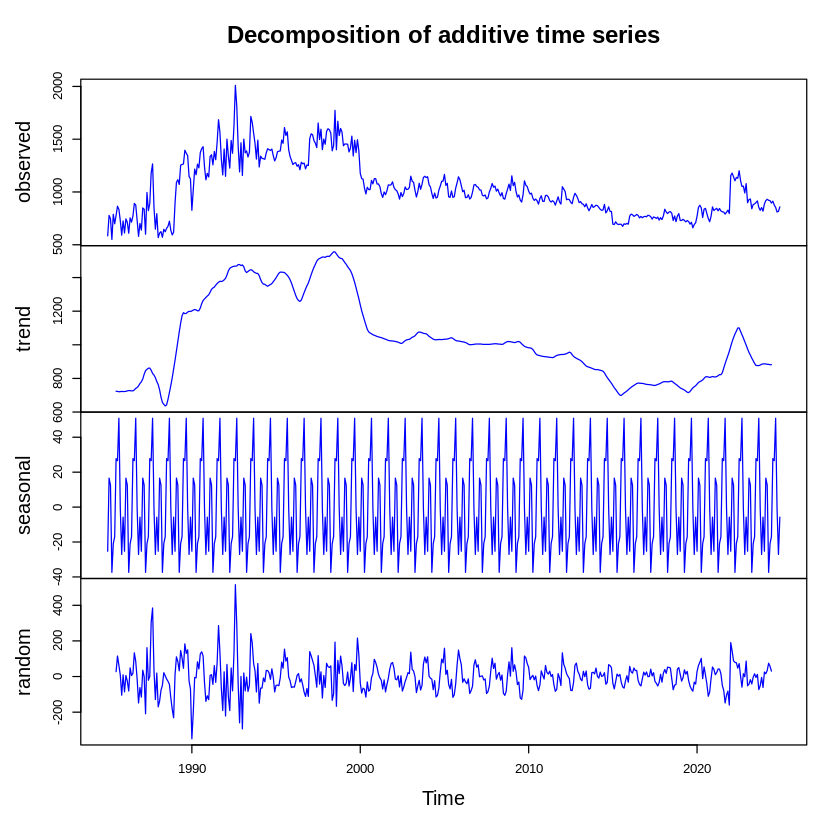

In [ ]:
# 4. Criar o objeto de Série Temporal
# Frequência 12 (mensal), começando em janeiro de 1985
ts_brumadinho <- ts(vetor_agua, start = c(1985, 1), frequency = 12)

# Visualizar a série completa e a sua decomposição
plot(ts_brumadinho, main = "Superfície de Água Mensal - Brumadinho (1985-2024)",
     ylab = "Área (ha)", xlab = "Ano", col = "darkblue", lwd = 2)
plot(decompose(ts_brumadinho), col="blue")

# Teste de Estacionariedade (Dickey-Fuller)
adf.test(ts_brumadinho)

In [ ]:
# ==============================================================================
# 5. DIVISÃO TREINO E TESTE (O Pulo do Gato)
# Vamos treinar o modelo ANTES do desastre (1985 até Dezembro de 2018)
# E testar a previsão DURANTE e APÓS o desastre (Janeiro de 2019 a 2024)
# ==============================================================================

# Divisão dos dados
ts_treino <- window(ts_brumadinho, end = c(2018, 12))
ts_teste  <- window(ts_brumadinho, start = c(2019, 1))

# O horizonte de previsão 'h' é o número de meses na base de teste (6 anos = 72 meses)
horizonte <- length(ts_teste)

Series: ts_treino 
ARIMA(0,1,1)(0,1,2)[12] 

Coefficients:
          ma1     sma1     sma2
      -0.3024  -0.5822  -0.0747
s.e.   0.0502   0.0486   0.0456

sigma^2 = 6945:  log likelihood = -2309.14
AIC=4626.29   AICc=4626.39   BIC=4642.2

Training set error measures:
                   ME     RMSE      MAE        MPE     MAPE      MASE
Training set -0.26596 81.68424 53.66602 -0.1986375 4.980499 0.5153482
                    ACF1
Training set 0.004236714


	Ljung-Box test

data:  Residuals from ARIMA(0,1,1)(0,1,2)[12]
Q* = 36.406, df = 21, p-value = 0.01967

Model df: 3.   Total lags used: 24



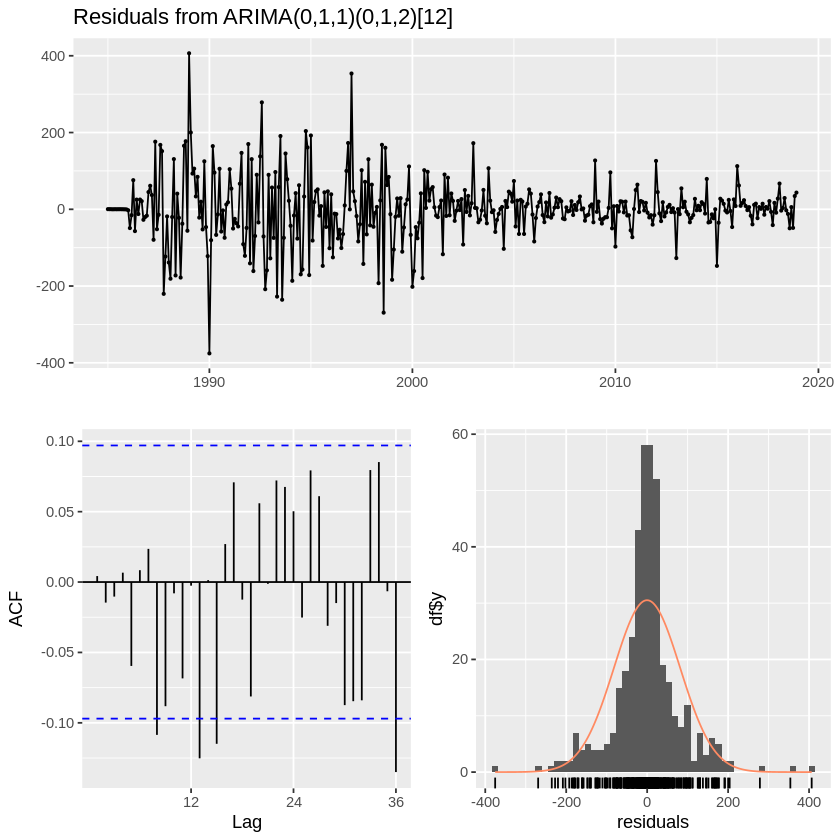

In [ ]:
# ==============================================================================
# 6. MODELAGEM (Treinando os Modelos)
# ==============================================================================

# A) Suavização Exponencial Simples (SES)
modelo_ses <- ses(ts_treino, h = horizonte)

# B) Modelo de Holt (Tendência)
modelo_holt <- holt(ts_treino, h = horizonte)

# C) Modelo Holt-Winters (Tendência e Sazonalidade)
modelo_hw <- hw(ts_treino, h = horizonte)

# D) Metodologia Box-Jenkins (ARIMA)
# O auto.arima encontra o melhor modelo com base no menor AIC
modelo_arima <- auto.arima(ts_treino)
prev_arima <- forecast(modelo_arima, h = horizonte)

# Resumo do melhor modelo ARIMA escolhido e Diagnóstico
summary(modelo_arima) # Aqui vocês olham o valor do AIC para o relatório!
checkresiduals(modelo_arima) # Gráficos de resíduos (parte importante da avaliação)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,0.5214508,100.5968,65.47474,-0.5037415,6.183773,0.6287459,0.01636019,NA
Test set,84.6599594,153.7270,112.32785,7.9303916,11.818007,1.0786706,0.87438514,2.084856


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.1706486,100.6455,65.58999,-0.5846572,6.205509,0.6298526,0.01625344,NA
Test set,74.1045636,145.8070,103.27204,6.7446783,10.836925,0.9917088,0.86993352,1.97243


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.493436,88.95154,59.49311,-0.412990,5.666514,0.5713051,0.2526147,NA
Test set,61.666056,137.35979,95.01751,5.365021,9.998922,0.9124415,0.8604764,1.857063


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.26596,81.68424,53.66602,-0.1986375,4.980499,0.5153482,0.004236714,NA
Test set,74.67864,147.15171,106.47272,6.8070312,11.240845,1.0224445,0.873291521,1.992927


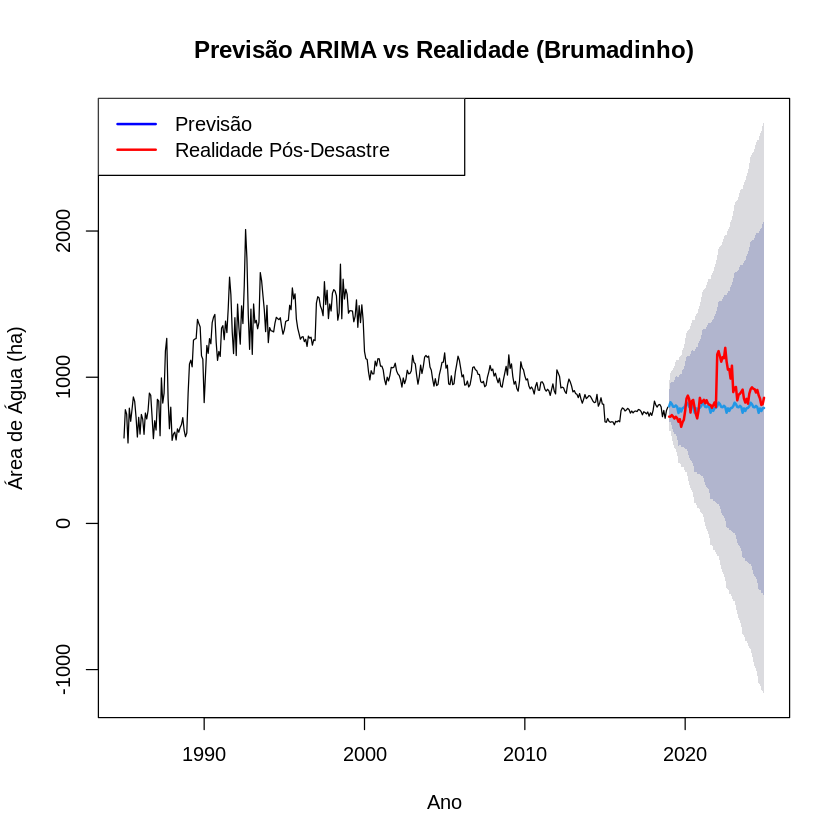

In [ ]:
# ==============================================================================
# 7. AVALIAÇÃO E PREVISÃO (RMSE)
# ==============================================================================

# Vamos gerar um gráfico comparando a previsão do melhor modelo com a realidade
plot(prev_arima, main = "Previsão ARIMA vs Realidade (Brumadinho)",
     ylab = "Área de Água (ha)", xlab = "Ano")
lines(ts_teste, col = "red", lwd = 2) # A linha vermelha é o que aconteceu de verdade
legend("topleft", legend = c("Previsão", "Realidade Pós-Desastre"),
       col = c("blue", "red"), lty = 1, lwd = 2)

# Comparar a precisão (RMSE) de todos os modelos na base de TESTE
# A função accuracy retorna várias métricas, o RMSE é a segunda coluna
accuracy(modelo_ses, ts_teste)
accuracy(modelo_holt, ts_teste)
accuracy(modelo_hw, ts_teste)
accuracy(prev_arima, ts_teste)